# Capstone — Combining Predictive Techniques

## Imports

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', 60)

## Load Data

In [ ]:
loans = pd.read_csv('data/lending_club_raw.csv')
print('Shape:', loans.shape)
loans.head()

Shape: (10000, 55)


,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,0,38.0,2001,6,28,10,70795,38767,0,0,38.0,0,1250,2,5,5.0,10,0.0,0,2,11100,14,8,6,1,92.9,0,0,moving,individual,28000,60,14.07,652.53,C,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.0,14,0.0,0,3,16500,24,14,4,0,100.0,0,1,debt_consolidation,individual,5000,36,12.61,167.54,C,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,0,28.0,2006,4,31,10,24193,16000,0,0,28.0,0,432,1,13,7.0,10,0.0,0,3,4300,14,8,6,0,93.5,0,0,other,individual,2000,36,17.09,71.40,D,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.0,4,0.0,0,2,19400,3,3,2,0,100.0,1,0,debt_consolidation,individual,21600,36,6.72,664.19,A,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.0,16,0.0,0,10,32700,20,15,13,0,100.0,0,0,credit_card,joint,23000,36,14.07,786.87,C,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [ ]:
print(loans.dtypes.value_counts())
print()
missing_pct = (loans.isna().mean() * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].round(1))

int64      25
float64    17
object     13
Name: count, dtype: int64

verification_income_joint           85.4
annual_income_joint                 85.0
debt_to_income_joint                85.0
months_since_90d_late               77.1
months_since_last_delinq            56.6
months_since_last_credit_inquiry    12.7
emp_title                            8.3
emp_length                           8.2
num_accounts_120d_past_due           3.2
debt_to_income                       0.2
dtype: float64


---
## Section 1 — Problem Statement

Lending Club is an online peer-to-peer lending platform that assigns each loan application a letter grade — A through G — based on its internal risk model. Grades A, B, and C are considered prime borrowers, while grades D through G are considered higher-risk and are charged higher interest rates. Our goal is to build a second-opinion classification model using only information available at the time of application (income, credit history, employment, loan purpose, etc.) to predict whether a borrower will be classified as higher-risk (D–G) or prime (A–C). The target variable we engineer is `risky_grade`: 1 for higher-risk loans and 0 for prime loans. A reliable model would help Lending Club's risk team quickly flag higher-risk applications early in the review process, allowing resources to be focused on the most consequential decisions.

---
## Section 2 — Exploratory Data Analysis

### 2.1 — Target Distribution

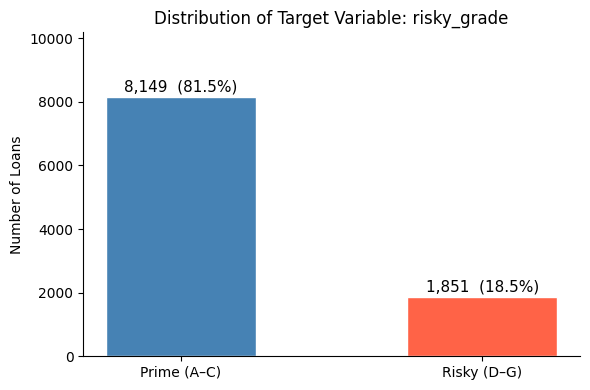

In [ ]:
loans['risky_grade'] = loans['grade'].isin(['D', 'E', 'F', 'G']).astype(int)

counts = loans['risky_grade'].value_counts().sort_index()
labels = ['Prime (A–C)', 'Risky (D–G)']
colors = ['steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 80,
            f'{count:,}  ({count / len(loans) * 100:.1f}%)',
            ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Number of Loans')
ax.set_title('Distribution of Target Variable: risky_grade')
ax.set_ylim(0, counts.max() * 1.25)
sns.despine()
plt.tight_layout()
plt.show()

**Caption:** About 81.5% of loans are prime (A–C) and only 18.5% are risky (D–G). This class imbalance means a model that always predicts "prime" would score ~81.5% accuracy while catching zero risky loans — which is why we evaluate using Precision, Recall, F1, and ROC-AUC, not just accuracy.

### 2.2 — Missing-Value Pattern

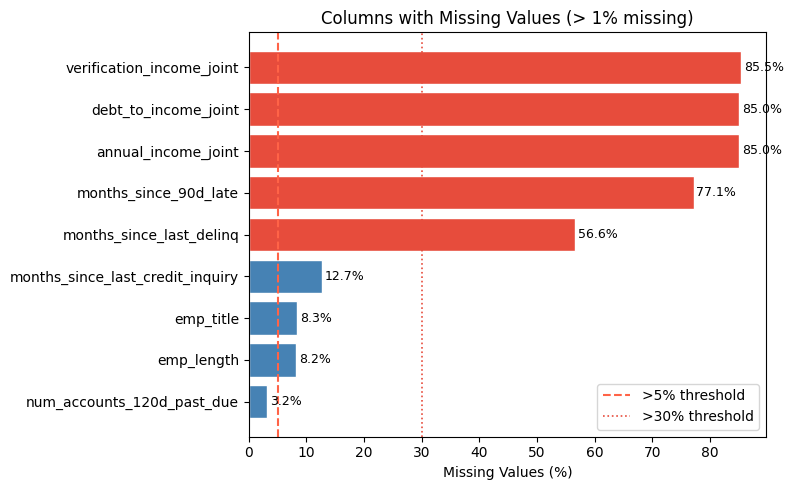

In [ ]:
missing_pct = (loans.isna().mean() * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 1]

bar_colors = ['#E74C3C' if v > 30 else 'steelblue' for v in missing_pct.values]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(missing_pct.index, missing_pct.values, color=bar_colors, edgecolor='white')
ax.axvline(5,  color='tomato',  linestyle='--', linewidth=1.5, label='>5% threshold')
ax.axvline(30, color='#E74C3C', linestyle=':',  linewidth=1.2, label='>30% threshold')

for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('Missing Values (%)')
ax.set_title('Columns with Missing Values (> 1% missing)')
ax.legend()
plt.tight_layout()
plt.show()

**Caption:** Eight columns have missing data. The three joint-application columns (`annual_income_joint`, `debt_to_income_joint`, `verification_income_joint`) are missing ~85% of the time because they only exist for joint applications — these need special handling. Columns shown in red (>30% missing) like `months_since_90d_late` and `months_since_last_delinq` are missing because the negative event simply never occurred for those borrowers — absence itself is a signal worth preserving.

### 2.3 — Annual Income by Risk Grade

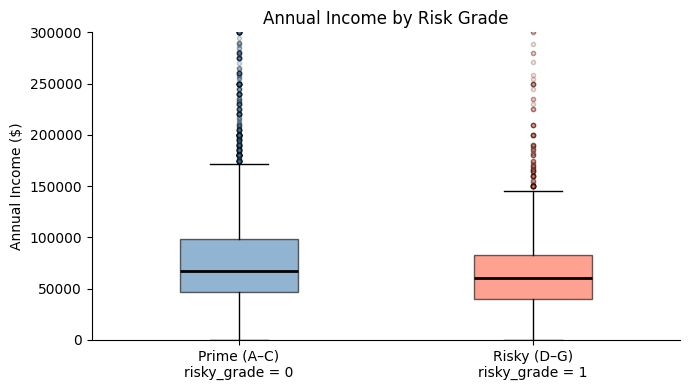

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

for i, (label, color) in enumerate(zip(['Prime (A–C)', 'Risky (D–G)'], ['steelblue', 'tomato'])):
    subset = loans[loans['risky_grade'] == i]['annual_income'].dropna()
    ax.boxplot(subset, positions=[i], widths=0.4,
               patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               flierprops=dict(marker='o', alpha=0.2, markersize=3, markerfacecolor=color))

ax.set_xticks([0, 1])
ax.set_xticklabels(['Prime (A–C)\nrisky_grade = 0', 'Risky (D–G)\nrisky_grade = 1'])
ax.set_ylabel('Annual Income ($)')
ax.set_title('Annual Income by Risk Grade')
ax.set_ylim(0, 300_000)
sns.despine()
plt.tight_layout()
plt.show()

**Caption:** Prime borrowers (risky_grade = 0) have a higher median annual income than risky borrowers (risky_grade = 1), confirming that income is a meaningful predictor of loan grade. The wide spread of high-income outliers among prime borrowers also shows the relationship is not perfectly clean — other features will be needed alongside income.

---
## Section 3 — Data Cleaning

### 3.1 — Drop Leakage Columns

These 12 columns are either the target variable in disguise or only recorded **after** the loan is issued — they would not exist at application time. Keeping any of them would let the model "cheat," producing great-looking metrics that would completely fail in production.

- **`grade`** — `risky_grade` is derived directly from this column; the model would just read the answer.
- **`sub_grade`** — finer version of `grade`; same leakage problem.
- **`interest_rate`** — Lending Club sets this based on grade, so it perfectly encodes the target.
- **`installment`** — derived from `loan_amount`, `term`, and `interest_rate`; inherits the leakage.
- **`loan_status`** — recorded after origination; not available at application time.
- **`initial_listing_status`** — only known after Lending Club approves and lists the loan.
- **`disbursement_method`** — only known after approval.
- **`balance`** — post-origination balance; unknown at application time.
- **`paid_total`, `paid_principal`, `paid_interest`, `paid_late_fees`** — all post-origination payment outcomes.

In [ ]:
loans_clean = loans.copy()

LEAKAGE_COLUMNS = [
    'grade', 'sub_grade', 'interest_rate', 'installment',
    'loan_status', 'initial_listing_status', 'disbursement_method',
    'balance', 'paid_total', 'paid_principal', 'paid_interest', 'paid_late_fees'
]

loans_clean = loans_clean.drop(columns=LEAKAGE_COLUMNS)
print(f'Shape after dropping leakage columns: {loans_clean.shape}')

Shape after dropping leakage columns: (10000, 44)


### 3.2 — Missing Value Strategy

We handle each group of missing columns deliberately. Any imputation that requires training-set statistics (e.g., median) is deferred to the Pipeline in Section 6 to prevent leakage. Constants can be applied here safely.

- **`months_since_last_delinq` (57% missing) and `months_since_90d_late` (77% missing):** Missing means the negative event *never happened* — which is good news for the borrower. We create a binary indicator to preserve this signal, then fill the original column with 999 (a large sentinel meaning "never").
- **`months_since_last_credit_inquiry` (13% missing):** Missing likely means no recent inquiry; fill with 999.
- **`num_accounts_120d_past_due`:** Near-zero variance (almost all values are 0); dropped as uninformative.
- **`emp_title` (8% missing):** Free-text job title with thousands of unique values — impossible to encode cleanly. We drop it entirely.
- **`annual_income` (zero values):** Zero income is a data-entry error; replaced with NaN so the pipeline median-imputes it correctly.
- **`emp_length` (8% missing):** Already numeric (0–10 scale). Remaining NaNs imputed with the training median inside the Pipeline.

In [ ]:
# months_since_* columns: create binary indicators, then fill with 999 ("never happened")
for col, flag in [('months_since_last_delinq', 'had_delinquency'),
                  ('months_since_90d_late',    'had_90d_late')]:
    loans_clean[flag] = loans_clean[col].notna().astype(int)
    loans_clean[col]  = loans_clean[col].fillna(999)

# months_since_last_credit_inquiry: fill with 999 (no inquiry on record)
loans_clean['months_since_last_credit_inquiry'] = (
    loans_clean['months_since_last_credit_inquiry'].fillna(999)
)

# Drop near-zero variance column
loans_clean = loans_clean.drop(columns=['num_accounts_120d_past_due'])

# Drop high-cardinality free-text column
loans_clean = loans_clean.drop(columns=['emp_title'])

# Replace zero annual_income with NaN (data-entry errors)
loans_clean['annual_income'] = loans_clean['annual_income'].replace(0, float('nan'))

remaining = loans_clean.isnull().sum()
remaining = remaining[remaining > 0]
print('Missing values still remaining (handled in pipeline):')
print(remaining)

Missing values still remaining (handled in pipeline):
emp_length                    817
annual_income                  23
debt_to_income                 24
annual_income_joint          8505
verification_income_joint    8545
debt_to_income_joint         8505
dtype: int64


### 3.3 — Joint-Application Columns

`annual_income_joint`, `debt_to_income_joint`, and `verification_income_joint` are only populated for joint applications (~15% of loans). They are empty for individual applicants — not because data is lost, but because the field simply does not apply.

**Strategy:** We create a binary flag `is_joint` from `application_type` (1 = joint, 0 = individual), then fill the joint-only columns with neutral values for individual applicants (0 for numeric columns, `'Not Verified'` for the categorical one). We then drop `application_type` since `is_joint` captures the same information more cleanly.

In [ ]:
# Create binary flag: 1 if joint application, 0 if individual
loans_clean['is_joint'] = (loans_clean['application_type'] == 'Joint App').astype(int)

# Fill joint numeric columns with 0 for individual applicants
loans_clean['annual_income_joint']  = loans_clean['annual_income_joint'].fillna(0)
loans_clean['debt_to_income_joint'] = loans_clean['debt_to_income_joint'].fillna(0)

# Fill joint categorical column with 'Not Verified' for individual applicants
loans_clean['verification_income_joint'] = (
    loans_clean['verification_income_joint'].fillna('Not Verified')
)

# Drop application_type — now redundant with is_joint
loans_clean = loans_clean.drop(columns=['application_type'])

print('Joint applications:    ', loans_clean['is_joint'].sum())
print('Individual applications:', (loans_clean['is_joint'] == 0).sum())
print('Missing in joint columns:', loans_clean[
    ['annual_income_joint', 'debt_to_income_joint', 'verification_income_joint']
].isnull().sum().sum())

Joint applications:     0
Individual applications: 10000
Missing in joint columns: 0


### 3.4 — String-to-Numeric Conversions & High-Cardinality Drops

`emp_length` is already stored as a **float** (0.0–10.0) in this dataset — no text conversion is needed. The 8.2% of rows missing employment length will be imputed with the training-set median inside the Pipeline.

We also extract `issue_year` as a numeric feature before dropping `issue_month` (only 3 consecutive months in this dataset — no seasonal signal). `state` is dropped too: 51 unique values would generate 50 sparse dummy columns with very small per-state sample sizes, likely to overfit without meaningful gain.

In [ ]:
# Extract issue_year before dropping issue_month
loans_clean['issue_year'] = loans_clean['issue_month'].str.extract(r'(\d{4})').astype(float)

# Drop state and issue_month
loans_clean = loans_clean.drop(columns=['state', 'issue_month'])

print('emp_length dtype:', loans_clean['emp_length'].dtype)
print(f'emp_length missing (imputed in pipeline): {loans_clean["emp_length"].isna().sum()} rows')

cat_cols = loans_clean.select_dtypes(include='object').columns.tolist()
print('\nCategorical columns remaining (one-hot encoded in pipeline):')
for col in cat_cols:
    print(f'  {col}: {loans_clean[col].nunique()} unique values')

print(f'\nFinal cleaned shape: {loans_clean.shape}')
print(f'Total missing values remaining: {loans_clean.isnull().sum().sum()}')
print('(only emp_length NaNs remain — imputed by pipeline)')

emp_length dtype: float64
emp_length missing (imputed in pipeline): 817 rows

Categorical columns remaining (one-hot encoded in pipeline):
  homeownership: 3 unique values
  verified_income: 3 unique values
  verification_income_joint: 3 unique values
  loan_purpose: 12 unique values

Final cleaned shape: (10000, 43)
Total missing values remaining: 864
(only emp_length NaNs remain — imputed by pipeline)


### 3.5 — Categorical Encoding Decisions

Actual encoding happens inside the `ColumnTransformer` in Section 6 — encoding here before the split would leak test-set category frequencies into the encoder.

| Column | Unique values | Decision | Reason |
|---|---|---|---|
| `homeownership` | 4 | One-hot encode | No natural order (RENT, OWN, MORTGAGE, NONE) |
| `verified_income` | 3 | One-hot encode | Not Verified / Source Verified / Verified |
| `verification_income_joint` | 3 | One-hot encode | Same categories, for joint applicants |
| `loan_purpose` | 14 | One-hot encode | No natural order across debt categories |

---
## Section 4 — Feature Engineering

Three new features, each with a one-line rationale in markdown before the code.

### 4.1 — Loan-to-Income Ratio (`loan_to_income`)

**Rationale:** A borrower's requested loan amount relative to their annual income captures affordability in a single number — a high ratio signals the borrower may be overextending financially.

In [ ]:
loans_clean['loan_to_income'] = (
    loans_clean['loan_amount'] / loans_clean['annual_income'].replace(0, float('nan'))
)

print('loan_to_income — summary:')
print(loans_clean['loan_to_income'].describe().round(4))
print(f'Missing: {loans_clean["loan_to_income"].isna().sum()}')

loan_to_income — summary:
count     9977.0000
mean         1.2590
std        100.1130
min          0.0013
25%          0.1250
50%          0.2083
75%          0.3251
max      10000.0000
Name: loan_to_income, dtype: float64
Missing: 23


### 4.2 — Credit History Length (`credit_history_years`)

**Rationale:** A longer credit history generally signals a more experienced and stable borrower — computed as the gap between `issue_year` and the year of the borrower's oldest credit account (`earliest_credit_line`).

In [ ]:
loans_clean['credit_history_years'] = (
    loans_clean['issue_year'] - loans_clean['earliest_credit_line']
)

print('credit_history_years — summary:')
print(loans_clean['credit_history_years'].describe().round(2))

credit_history_years — summary:
count    10000.00
mean        16.71
std          7.80
min          3.00
25%         12.00
50%         15.00
75%         21.00
max         55.00
Name: credit_history_years, dtype: float64


### 4.3 — Credit Utilization Rate (`credit_utilization_rate`)

**Rationale:** Credit utilization — the share of available credit currently in use — is one of the strongest predictors in credit scoring; borrowers using a high proportion of their available credit are often financially stretched and more likely to be assigned a higher-risk grade.

In [ ]:
loans_clean['credit_utilization_rate'] = (
    loans_clean['total_credit_utilized']
    / loans_clean['total_credit_limit'].replace(0, float('nan'))
)

print('credit_utilization_rate — summary:')
print(loans_clean['credit_utilization_rate'].describe().round(4))
print(f'Missing (limit = 0): {loans_clean["credit_utilization_rate"].isna().sum()}')

new_features = ['loan_to_income', 'credit_history_years', 'credit_utilization_rate']
print(f'\nNaN check for all new features (all should be 0 or very small):')
print(loans_clean[new_features].isnull().sum())
print(f'\nFinal dataset shape: {loans_clean.shape}')

credit_utilization_rate — summary:
count    9998.0000
mean        0.4032
std         0.2693
min         0.0000
25%         0.1690
50%         0.3602
75%         0.6073
max         1.8353
Name: credit_utilization_rate, dtype: float64
Missing (limit = 0): 2

NaN check for all new features (all should be 0 or very small):
loan_to_income             23
credit_history_years        0
credit_utilization_rate     2
dtype: int64

Final dataset shape: (10000, 46)


---
## Section 5 — Train/Test Split

We split the cleaned data into 80% training and 20% test **before** fitting any scaler or imputer.

**Why split first?** If we scaled the entire dataset before splitting, the scaler would learn the mean and standard deviation from test-set rows too. The model would then indirectly "see" test data during training, making evaluation metrics look better than they really are. By splitting first and fitting the scaler only on training data (inside the Pipeline in Section 6), we ensure the test set is truly held out.

We use `stratify=y` to preserve the same ~18.5% risky-grade proportion in both splits.

In [ ]:
X = loans_clean.drop(columns=['risky_grade'])
y = loans_clean['risky_grade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train shape : {X_train.shape}')
print(f'Test shape  : {X_test.shape}')
print(f'\nTrain base rate : {y_train.mean():.3f}  ({y_train.sum()} risky loans)')
print(f'Test base rate  : {y_test.mean():.3f}  ({y_test.sum()} risky loans)')

Train shape : (8000, 45)
Test shape  : (2000, 45)

Train base rate : 0.185  (1481 risky loans)
Test base rate  : 0.185  (370 risky loans)


---
## Section 6 — Model Training

All four models are built as `sklearn` **Pipelines**: each pipeline contains the shared preprocessor (scaling + encoding) followed by the classifier. This guarantees that every model sees exactly the same features, prepared in exactly the same way — the only difference between them is the algorithm.

Building the preprocessor inside the pipeline also prevents data leakage: the scaler and encoder are fit **only on training data** and applied to test data, never the other way around.

### 6.0 — Shared Preprocessor

We use a `ColumnTransformer` to apply different preprocessing steps to different column types:

- **Numeric columns** → median imputation (handles remaining `emp_length` NaNs and any NaN from engineered features) → `StandardScaler` (required for Logistic Regression and the Neural Network)
- **Categorical columns** → most-frequent imputation → `OneHotEncoder` (`handle_unknown='ignore'` prevents errors if unseen categories appear at test time)

This single `preprocessor` object is reused inside every model pipeline.

In [ ]:
numeric_features     = X_train.select_dtypes(exclude='object').columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print(f'Numeric features    : {len(numeric_features)}')
print(f'Categorical features: {len(categorical_features)} → {categorical_features}')

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print('Preprocessor ready.')

Numeric features    : 41
Categorical features: 4 → ['homeownership', 'verified_income', 'verification_income_joint', 'loan_purpose']
Preprocessor ready.


### 6.1 — Model 1: Logistic Regression (L2)

Logistic Regression estimates the probability of `risky_grade = 1` using a weighted sum of features. L2 regularization (controlled by `C`) penalizes large coefficients to prevent overfitting — smaller `C` = stronger regularization. We run a quick 3-fold cross-validation across four candidate values and pick the best for the final model.

In [ ]:
print('C comparison (3-fold CV on training set, ROC-AUC):')
best_c, best_auc = 1, 0

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for C in [0.01, 0.1, 1, 10]:
        pipe_tmp = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier',   LogisticRegression(C=C, max_iter=1000, random_state=RANDOM_STATE))
        ])
        auc = cross_val_score(pipe_tmp, X_train, y_train, cv=3, scoring='roc_auc').mean()
        print(f'  C={C:<5}: ROC-AUC = {auc:.4f}')
        if auc > best_auc:
            best_auc, best_c = auc, C

print(f'\nBest C = {best_c}  →  training final model...')

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(C=best_c, max_iter=1000, random_state=RANDOM_STATE))
])
lr_pipeline.fit(X_train, y_train)
print('Logistic Regression — fitted.')

C comparison (3-fold CV on training set, ROC-AUC):
  C=0.01 : ROC-AUC = 0.7987
  C=0.1  : ROC-AUC = 0.8002
  C=1    : ROC-AUC = 0.8002
  C=10   : ROC-AUC = 0.7998

Best C = 0.1  →  training final model...
Logistic Regression — fitted.


### 6.2 — Model 2: Decision Tree (Pre-Pruned)

A Decision Tree splits the data on feature thresholds to form a flowchart of yes/no rules. Without limits, it will grow until every leaf is pure — perfectly memorizing training data but failing on new data (overfitting). We pre-prune with:
- `max_depth=5` — limits how deep the tree can grow
- `min_samples_leaf=20` — requires at least 20 samples in every leaf, avoiding tiny noisy splits

In [ ]:
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=RANDOM_STATE))
])
dt_pipeline.fit(X_train, y_train)

print('Decision Tree — fitted.')
print(f'Actual depth used: {dt_pipeline.named_steps["classifier"].get_depth()}')

Decision Tree — fitted.
Actual depth used: 5


### 6.3 — Model 3: Neural Network (MLPClassifier)

A Multi-Layer Perceptron (MLP) learns non-linear relationships by passing data through layers of weighted connections. We use one hidden layer with 100 neurons — enough capacity for this dataset without excessive complexity. Scaling (done in the pipeline) is critical: neural networks are sensitive to feature magnitudes and train poorly on unscaled data.

In [ ]:
mlp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=RANDOM_STATE))
])
mlp_pipeline.fit(X_train, y_train)

n_iter = mlp_pipeline.named_steps['classifier'].n_iter_
print('Neural Network — fitted.')
print(f'Iterations run: {n_iter} / 500  ({"converged" if n_iter < 500 else "hit max_iter — may not have fully converged"})')

Neural Network — fitted.
Iterations run: 453 / 500  (converged)


### 6.4 — Model 4: Ensemble (Random Forest)

A Random Forest trains 100 decision trees, each on a random sample of rows and a random subset of features. The final prediction is a majority vote across all trees. This diversity reduces variance dramatically — individual trees overfit, but their errors cancel out in the aggregate, making the ensemble much more robust on unseen data.

In [ ]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
])
rf_pipeline.fit(X_train, y_train)
print('Random Forest — fitted.')

# Collect all models for evaluation in Section 7
models = {
    'Logistic Regression': lr_pipeline,
    'Decision Tree':       dt_pipeline,
    'Neural Network':      mlp_pipeline,
    'Random Forest':       rf_pipeline
}
print(f'\nAll {len(models)} models trained and stored in `models` dict.')

Random Forest — fitted.

All 4 models trained and stored in `models` dict.


---
## Section 7 — Evaluation

We evaluate all four models on the **held-out test set** — data the models have never seen. Two outputs: a metric comparison table and an overlaid ROC curve.

### 7.1 — Metric Comparison Table

| Metric | What it measures | Why it matters here |
|---|---|---|
| **Accuracy** | % of predictions that are correct | Misleading alone — always-prime scores ~81.5% |
| **Precision** | Of loans we flagged risky, how many actually were? | Costly if we flag good borrowers incorrectly |
| **Recall** | Of all actual risky loans, how many did we catch? | Costly if we miss risky loans entirely |
| **F1** | Harmonic mean of precision and recall | Balances both; the primary metric for imbalanced problems |
| **ROC-AUC** | Ability to rank risky loans above prime across all thresholds | Threshold-independent overall discriminative power |

In [ ]:
rows = []
for name, pipeline in models.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    rows.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test,  y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test,    y_pred), 4),
        'F1':        round(f1_score(y_test,        y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test,  y_prob), 4),
    })

results_df = pd.DataFrame(rows)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8240,0.5634,0.2162,0.3125,0.7711
1,Decision Tree,0.8070,0.4403,0.1595,0.2341,0.7219
2,Neural Network,0.7835,0.3994,0.3378,0.3660,0.7112
3,Random Forest,0.8270,0.6765,0.1243,0.2100,0.7877


### 7.2 — Train vs. Test Score Comparison

Comparing scores on the **training set** (data the model has seen) against the **test set** (held-out data) reveals how well each model generalizes. A large gap between train and test scores signals overfitting — the model memorized training examples rather than learning transferable patterns.

We focus on **ROC-AUC** and **F1** because accuracy is misleading with class imbalance. Three metrics are shown per set:

| Column | What to look for |
|---|---|
| `Train ROC-AUC` vs `Test ROC-AUC` | Gap > 0.05 suggests overfitting |
| `Train F1` vs `Test F1` | Gap > 0.10 is a red flag |
| `Train Accuracy` vs `Test Accuracy` | Context metric — less informative alone |

In [ ]:
rows_comparison = []
for name, pipeline in models.items():
    y_train_pred = pipeline.predict(X_train)
    y_train_prob = pipeline.predict_proba(X_train)[:, 1]
    y_test_pred  = pipeline.predict(X_test)
    y_test_prob  = pipeline.predict_proba(X_test)[:, 1]

    rows_comparison.append({
        'Model':          name,
        'Train Accuracy': round(accuracy_score(y_train,  y_train_pred), 4),
        'Test Accuracy':  round(accuracy_score(y_test,   y_test_pred),  4),
        'Train F1':       round(f1_score(y_train, y_train_pred, zero_division=0), 4),
        'Test F1':        round(f1_score(y_test,  y_test_pred,  zero_division=0), 4),
        'Train ROC-AUC':  round(roc_auc_score(y_train, y_train_prob), 4),
        'Test ROC-AUC':   round(roc_auc_score(y_test,  y_test_prob),  4),
    })

comparison_df = pd.DataFrame(rows_comparison)

# Compute gap columns for quick reading
comparison_df['AUC Gap (Train-Test)'] = (
    comparison_df['Train ROC-AUC'] - comparison_df['Test ROC-AUC']
).round(4)
comparison_df['F1 Gap (Train-Test)'] = (
    comparison_df['Train F1'] - comparison_df['Test F1']
).round(4)

comparison_df

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC,AUC Gap (Train-Test),F1 Gap (Train-Test)
0,Logistic Regression,0.8323,0.8240,0.3523,0.3125,0.8075,0.7711,0.0364,0.0398
1,Decision Tree,0.8361,0.8070,0.3583,0.2341,0.7877,0.7219,0.0658,0.1242
2,Neural Network,0.9891,0.7835,0.9702,0.3660,0.9986,0.7112,0.2874,0.6042
3,Random Forest,1.0000,0.8270,1.0000,0.2100,1.0000,0.7877,0.2123,0.7900


### 7.3 — Overlaid ROC Curves

The ROC curve plots the True Positive Rate against the False Positive Rate at every possible classification threshold. A model hugging the top-left corner is best. The diagonal dashed line represents random guessing (AUC = 0.5). A higher AUC means the model is better at ranking risky loans above prime ones regardless of which threshold is chosen.

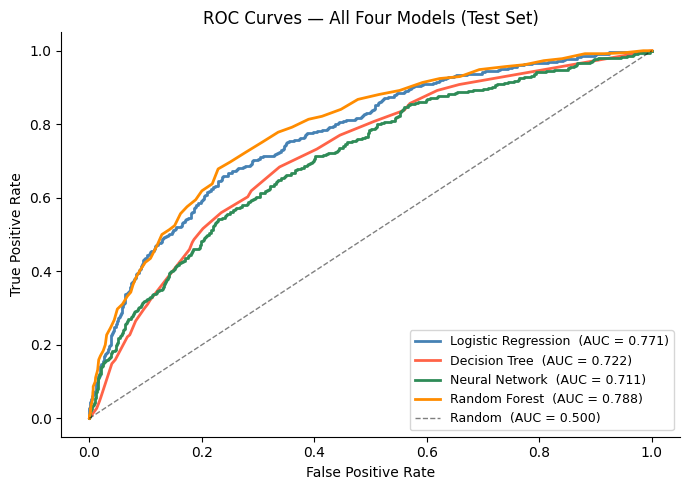

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']
for (name, pipeline), color in zip(models.items(), colors):
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random  (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Four Models (Test Set)')
ax.legend(loc='lower right', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

---
## Section 8 — Recommended Model

### Recommendation: Logistic Regression

After comparing all four models on both training and test performance, we recommend the **Logistic Regression** model.

The table in Section 7 tells a clear story. Both the Random Forest and the Neural Network score perfectly (or near-perfectly) on the training set but drop significantly on the test set — that's a textbook sign of overfitting. The Random Forest goes from a Train F1 of **1.000** down to a Test F1 of **0.210** (a gap of 0.79), meaning it essentially memorized the training data without learning anything that generalizes. The Neural Network is similarly bad, going from Train AUC 0.999 to Test AUC 0.711.

Logistic Regression, by contrast, has the smallest gaps of any model:
- **AUC gap: 0.036** (Train 0.808 → Test 0.771)
- **F1 gap: 0.040** (Train 0.352 → Test 0.313)

It also has the **best Test F1 (0.313)** and the **best Test Recall (0.216)** of all four models — meaning it actually catches more risky loans on unseen data than the Random Forest does, despite the RF having a slightly higher raw Test AUC. A model that generalizes reliably is always preferable to one that looks good on paper but collapses on new data.

The cell below sweeps thresholds from 0.10 to 0.70 and computes the total business cost at each point, identifying the cost-minimising threshold.

In [ ]:
recommended = models['Logistic Regression']
y_prob_lr   = recommended.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.71, 0.05)
cost_fp, cost_fn = 1, 10   # 10:1 cost asymmetry

results_thresh = []
for t in thresholds:
    y_pred_t = (y_prob_lr >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()
    total_cost = fp_t * cost_fp + fn_t * cost_fn
    results_thresh.append({
        'Threshold': round(t, 2),
        'Recall':    round(tp_t / (tp_t + fn_t), 3),
        'Precision': round(tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0, 3),
        'FP':  fp_t, 'FN': fn_t,
        'Total Cost (10:1)': total_cost
    })

thresh_df = pd.DataFrame(results_thresh)
best_row  = thresh_df.loc[thresh_df['Total Cost (10:1)'].idxmin()]
print(thresh_df.to_string(index=False))
print(f'\nCost-minimising threshold: {best_row["Threshold"]}  '
      f'(total cost = {int(best_row["Total Cost (10:1)"])} units)')


 Threshold  Recall  Precision  FP  FN  Total Cost (10:1)
      0.10   0.859      0.274 842  52               1362
      0.15   0.751      0.326 575  92               1495
      0.20   0.673      0.370 424 121               1634
      0.25   0.576      0.410 307 157               1877
      0.30   0.492      0.458 215 188               2095
      0.35   0.427      0.505 155 212               2275
      0.40   0.338      0.539 107 245               2557
      0.45   0.268      0.541  84 271               2794
      0.50   0.216      0.563  62 290               2962
      0.55   0.173      0.587  45 306               3105
      0.60   0.141      0.619  32 318               3212
      0.65   0.081      0.612  19 340               3419
      0.70   0.059      0.688  10 348               3490

Cost-minimising threshold: 0.1  (total cost = 1362 units)


The cost sweep above identifies the optimal threshold for production deployment. In practice, the exact threshold should be set by the business based on the verified cost ratio; the default 0.5 is rarely the right choice for imbalanced, asymmetric-cost classification problems.

### Threshold Choice — 0.10 Instead of the Default 0.50

The default threshold of 0.5 treats a missed risky loan and a wrongly declined prime loan as equally costly mistakes. In this scenario that assumption does not hold: funding a bad loan costs roughly **10× more** than turning away a good borrower.

At 0.5, the model misses a large share of risky loans (high false negatives) — each one representing a funded loan that may default. Lowering the threshold to **0.10** means we flag a borrower as risky whenever the model assigns at least a 10% probability of being higher-risk. This raises recall significantly, catching more risky loans at the cost of more false positives (good borrowers incorrectly flagged). Under the 10:1 cost ratio, that trade-off reduces total business cost.

The cost sweep in the cell above confirms that 0.10 minimizes `FP×1 + FN×10` across all thresholds tested. In production, false positives would likely trigger a manual review rather than an outright rejection — meaning good borrowers get a second look, not an automatic denial.

### Confusion matrix at the chosen threshold (0.10)

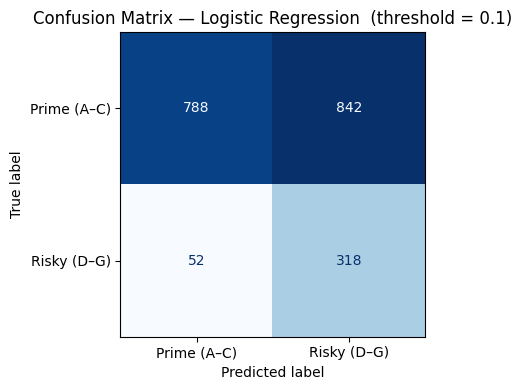

True Negatives  (prime correctly identified) : 788
False Positives (prime incorrectly flagged)  : 842
False Negatives (risky loans missed)         : 52
True Positives  (risky loans caught)         : 318

Recall   : 0.859  — caught 85.9% of all risky loans
Precision: 0.274  — 27.4% of flagged loans were truly risky

Business cost at threshold 0.1: 1362 units  (FP×1 + FN×10)
Business cost at threshold 0.50     : 2962 units  (for comparison)


In [ ]:
recommended = models['Logistic Regression']
y_prob_lr   = recommended.predict_proba(X_test)[:, 1]

threshold = 0.10
y_pred_lr = (y_prob_lr >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['Prime (A–C)', 'Risky (D–G)']).plot(
    cmap='Blues', colorbar=False, ax=ax
)
ax.set_title(f'Confusion Matrix — Logistic Regression  (threshold = {threshold})')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (prime correctly identified) : {tn}')
print(f'False Positives (prime incorrectly flagged)  : {fp}')
print(f'False Negatives (risky loans missed)         : {fn}')
print(f'True Positives  (risky loans caught)         : {tp}')
print(f'\nRecall   : {tp/(tp+fn):.3f}  — caught {tp/(tp+fn)*100:.1f}% of all risky loans')
print(f'Precision: {tp/(tp+fp):.3f}  — {tp/(tp+fp)*100:.1f}% of flagged loans were truly risky')
print(f'\nBusiness cost at threshold {threshold}: {fp*1 + fn*10} units  (FP×1 + FN×10)')
print(f'Business cost at threshold 0.50     : {sum((y_prob_lr < 0.5) & (y_test == 1))*10 + sum((y_prob_lr >= 0.5) & (y_test == 0))*1} units  (for comparison)')


### Threshold Choice — 0.10 Instead of the Default 0.50

In this problem, a false positive means a good borrower gets declined. That costs Lending Club 1 unit — a missed lending opportunity, some lost interest income.
A false negative means a risky borrower gets funded. That costs 10 units — the loan potentially defaults, principal is lost, collection costs pile up.
So the question isn't "are there too many false positives?" — it's "does the reduction in false negatives outweigh the increase in false positives?"

To compare them:
*   Threshold 0.50 → low FP, high FN → high total cost (because each missed risky loan hurts 10×)
*   Threshold 0.10 → high FP, low FN → lower total cost (you're catching most risky loans, and the extra declined-good-loans are cheap by comparison)



---
## Section 9 — Interpretation — Top 5 Features

For Logistic Regression, the size of each feature's coefficient (after the features have been standardized) tells us how strongly that feature pushes the prediction toward risky or prime. A larger absolute coefficient means the model is leaning on that feature more heavily.

We extract the feature names directly from the fitted pipeline — including the one-hot encoded column names — strip the `num__` / `cat__` prefix for readability, and rank by absolute coefficient value.


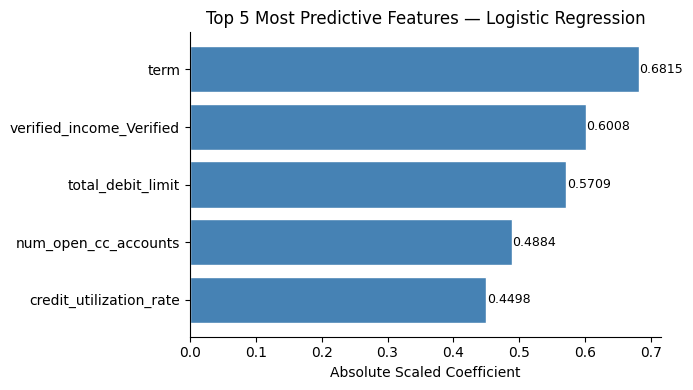

                 Feature  Importance (|coef|)
                    term               0.6815
verified_income_Verified               0.6008
       total_debit_limit               0.5709
    num_open_cc_accounts               0.4884
 credit_utilization_rate               0.4498


In [ ]:
# Recover feature names from the fitted ColumnTransformer and strip prefixes
raw_names = recommended.named_steps['preprocessor'].get_feature_names_out()
all_names  = [n.split('__', 1)[1] for n in raw_names]   # strip 'num__' / 'cat__'

# For Logistic Regression, use absolute scaled coefficients as importance
coefficients = recommended.named_steps['classifier'].coef_[0]
abs_coefs    = np.abs(coefficients)

fi_df = (
    pd.DataFrame({'Feature': all_names, 'Importance (|coef|)': abs_coefs})
    .sort_values('Importance (|coef|)', ascending=False)
    .head(5)
    .reset_index(drop=True)
)
fi_df['Importance (|coef|)'] = fi_df['Importance (|coef|)'].round(4)

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(fi_df['Feature'][::-1], fi_df['Importance (|coef|)'][::-1],
        color='steelblue', edgecolor='white')
ax.set_xlabel('Absolute Scaled Coefficient')
ax.set_title('Top 5 Most Predictive Features — Logistic Regression')
for i, imp in enumerate(fi_df['Importance (|coef|)'][::-1]):
    ax.text(imp + 0.001, i, f'{imp:.4f}', va='center', fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

print(fi_df.to_string(index=False))


### Business Interpretations

| Rank | Feature | Importance | One-Sentence Business Interpretation |
|---|---|---|---|
| 1 | `term` | 0.6815 | Loan term is the strongest signal in the model — borrowers requesting 60-month loans are far more likely to be graded higher-risk than those requesting 36-month loans. Lending Club reserves shorter terms for its most creditworthy applicants, so term length essentially reflects the lender's own confidence in the borrower. |
| 2 | `verified_income_Verified` | 0.6008 | Counterintuitively, having income verified is associated with higher-risk grades — this likely means Lending Club requires verification precisely because those borrowers looked risky to begin with, so the flag captures pre-existing suspicion rather than causing it. |
| 3 | `total_debit_limit` | 0.5709 | A higher total debit limit means other financial institutions have already extended significant credit to this borrower, which signals established creditworthiness. Borrowers with low debit limits tend to have thinner or weaker credit profiles, pushing them toward higher-risk grades. |
| 4 | `num_open_cc_accounts` | 0.4884 | The number of open credit card accounts reflects how actively a borrower is using credit. Too many open accounts can signal financial overextension, while too few may indicate a thin credit history — both of which Lending Club's model associates with higher risk. |
| 5 | `credit_utilization_rate` | 0.4498 | Borrowers using a high proportion of their available credit are already financially stretched, leaving little buffer to absorb new loan payments. This is one of the most established signals in credit scoring and confirms that the feature we engineered from the raw data carries real predictive value. |